# Conway's Game of Life
### A spatial cellular automaton with dissmodel

Conway's Game of Life is a classic example of how simple local rules
produce complex emergent behavior. Each cell is either **alive** (1)
or **dead** (0), and its next state depends only on its 8 neighbors.

## Rules

| Current state | Live neighbors | Next state |
|:---:|:---:|:---:|
| Alive | < 2 | Dies (underpopulation) |
| Alive | 2 or 3 | Survives |
| Alive | > 3 | Dies (overpopulation) |
| Dead | exactly 3 | Born |

> All other cells remain dead.

In [2]:
import random
from typing import Any

from libpysal.weights import Queen

from dissmodel.geo import FillStrategy, fill
from dissmodel.geo.vector.cellular_automaton import CellularAutomaton


# ---------------------------------------------------------------------------
# Built-in patterns
# ---------------------------------------------------------------------------

#: Classic Game of Life patterns organized by category.
#: Can be imported and used independently of :class:`GameOfLife`.
PATTERNS: dict[str, list[list[int]]] = {
    # --- Oscillators ---
    "blinker": [                        # period 2
        [1, 1, 1],
    ],
    "toad": [                           # period 2
        [0, 1, 1, 1],
        [1, 1, 1, 0],
    ],
    "beacon": [                         # period 2
        [1, 1, 0, 0],
        [1, 1, 0, 0],
        [0, 0, 1, 1],
        [0, 0, 1, 1],
    ],
    "pulsar": [                         # period 3 — requires grid >= 15x15
        [0,0,1,1,1,0,0,0,1,1,1,0,0],
        [0,0,0,0,0,0,0,0,0,0,0,0,0],
        [1,0,0,0,0,1,0,1,0,0,0,0,1],
        [1,0,0,0,0,1,0,1,0,0,0,0,1],
        [1,0,0,0,0,1,0,1,0,0,0,0,1],
        [0,0,1,1,1,0,0,0,1,1,1,0,0],
        [0,0,0,0,0,0,0,0,0,0,0,0,0],
        [0,0,1,1,1,0,0,0,1,1,1,0,0],
        [1,0,0,0,0,1,0,1,0,0,0,0,1],
        [1,0,0,0,0,1,0,1,0,0,0,0,1],
        [1,0,0,0,0,1,0,1,0,0,0,0,1],
        [0,0,0,0,0,0,0,0,0,0,0,0,0],
        [0,0,1,1,1,0,0,0,1,1,1,0,0],
    ],
    # --- Spaceships ---
    "glider": [                         # moves diagonally
        [0, 1, 0],
        [0, 0, 1],
        [1, 1, 1],
    ],
    "lwss": [                           # lightweight spaceship
        [0, 1, 0, 0, 1],
        [1, 0, 0, 0, 0],
        [1, 0, 0, 0, 1],
        [1, 1, 1, 1, 0],
    ],
    # --- Still lifes ---
    "block": [                          # never changes
        [1, 1],
        [1, 1],
    ],
    "beehive": [                        # never changes
        [0, 1, 1, 0],
        [1, 0, 0, 1],
        [0, 1, 1, 0],
    ],
    "loaf": [                           # never changes
        [0, 1, 1, 0],
        [1, 0, 0, 1],
        [0, 1, 0, 1],
        [0, 0, 1, 0],
    ],
}


# ---------------------------------------------------------------------------
# Model
# ---------------------------------------------------------------------------

class GameOfLife(CellularAutomaton):
    """
    Spatial cellular automaton implementation of Conway's Game of Life.

    Cells live or die based on the number of live neighbors according to
    the following rules:

    - A live cell with fewer than 2 or more than 3 live neighbors dies.
    - A live cell with 2 or 3 live neighbors survives.
    - A dead cell with exactly 3 live neighbors becomes alive.

    Parameters
    ----------
    gdf : geopandas.GeoDataFrame
        GeoDataFrame with geometries and a ``state`` attribute.
    **kwargs :
        Extra keyword arguments forwarded to
        :class:`~dissmodel.geo.CellularAutomaton`.

    Examples
    --------
    >>> from dissmodel.geo import vector_grid
    >>> from dissmodel.core import Environment
    >>> gdf = vector_grid(dimension=(5, 5), resolution=1, attrs={"state": 0})
    >>> env = Environment(end_time=3)
    >>> gol = GameOfLife(gdf=gdf)
    >>> gol.initialize()
    """

    def setup(self) -> None:
        """Build the Queen neighborhood for the grid."""
        self.create_neighborhood(strategy=Queen, use_index=True)

    def initialize(self) -> None:
        """
        Fill the grid with a random initial state.

        Uses a 60/40 live/dead split with a fixed seed for reproducibility.
        Override this method to define a custom initial state.
        """
        fill(
            strategy=FillStrategy.RANDOM_SAMPLE,
            gdf=self.gdf,
            attr="state",
            data={1: 0.6, 0: 0.4},
            seed=42,
        )

    def initialize_patterns(
        self,
        patterns: list[str] | None = None,
    ) -> None:
        """
        Place classic Game of Life patterns at random positions on the grid.

        Parameters
        ----------
        patterns : list of str, optional
            Pattern names to place. If ``None``, all patterns in
            :data:`PATTERNS` are used. Available keys: ``"blinker"``,
            ``"toad"``, ``"beacon"``, ``"pulsar"``, ``"glider"``,
            ``"lwss"``, ``"block"``, ``"beehive"``, ``"loaf"``.

        Notes
        -----
        Assumes a square grid. The ``"pulsar"`` pattern requires a grid
        of at least 15x15 to avoid out-of-range placement.
        """
        selected = (
            {k: PATTERNS[k] for k in patterns if k in PATTERNS}
            if patterns
            else PATTERNS
        )

        grid_dim = int(len(self.gdf) ** 0.5)

        for pattern in selected.values():
            start_x = random.randint(0, grid_dim - len(pattern[0]))   # col _ offset bounded by n_cols
            start_y = random.randint(0, grid_dim - len(pattern))     # row offset bounded by n_rows

            fill(
                strategy=FillStrategy.PATTERN,
                gdf=self.gdf,
                attr="state",
                pattern=pattern,
                start_x=start_x,
                start_y=start_y,
            )

    def rule(self, idx: Any) -> int:
        """
        Apply the Game of Life transition rule to cell ``idx``.

        Parameters
        ----------
        idx : any
            Index of the cell being evaluated.

        Returns
        -------
        int
            ``1`` if the cell is alive after the transition, ``0`` if dead.
        """
        state = self.gdf.loc[idx, self.state_attr]
        live_neighbors = (self.neighbor_values(idx, self.state_attr)).sum()

        if state == 1:
            return 1 if 2 <= live_neighbors <= 3 else 0
        return 1 if live_neighbors == 3 else 0


__all__ = ["GameOfLife", "PATTERNS"]

## Imports

In [3]:
from matplotlib.colors import ListedColormap

from dissmodel.core import Environment
from dissmodel.geo import vector_grid
from dissmodel.visualization.map import Map

## ⚠️ Important: instantiation order

The `Environment` must always be created **before** any model (`GameOfLife`, `Map`, `Chart`).
Models connect to the active environment automatically when instantiated —
if no environment exists yet, the connection fails.

```
Environment  →  GameOfLife  →  Map
     ↑               ↑          ↑
  first          second        third
```

In [4]:
# 1. Environment must be created first
env = Environment(start_time=0, end_time=15)

## Setting up the grid

We create a 20x20 abstract grid where every cell begins dead (`state=0`).

In [5]:
gdf = vector_grid(dimension=(20, 20), resolution=1, attrs={"state": 0})
gdf.head()

,geometry,state
id,,
0-0,"POLYGON ((1 0, 1 1, 0 1, 0 0, 1 0))",0
1-0,"POLYGON ((1 1, 1 2, 0 2, 0 1, 1 1))",0
2-0,"POLYGON ((1 2, 1 3, 0 3, 0 2, 1 2))",0
3-0,"POLYGON ((1 3, 1 4, 0 4, 0 3, 1 3))",0
4-0,"POLYGON ((1 4, 1 5, 0 5, 0 4, 1 4))",0


## Available patterns

dissmodel ships with classic Game of Life patterns grouped by category:

- **Oscillators** — return to initial state after N steps (`blinker`, `toad`, `beacon`, `pulsar`)
- **Spaceships** — move across the grid (`glider`, `lwss`)
- **Still lifes** — never change (`block`, `beehive`, `loaf`)

In [6]:
for name, pattern in PATTERNS.items():
    print(f"{name:10} — {len(pattern)}x{len(pattern[0])}")

blinker    — 1x3
toad       — 2x4
beacon     — 4x4
pulsar     — 13x13
glider     — 3x3
lwss       — 4x5
block      — 2x2
beehive    — 3x4
loaf       — 4x4


## Initializing the model

Two initialization options are available:

- `initialize()` — random 60/40 live/dead split
- `initialize_patterns([...])` — place classic patterns at random positions

In [7]:
# 2. Model connects to the active environment automatically
gol = GameOfLife(gdf=gdf)

# Choose one:
gol.initialize_patterns(["glider", "blinker", "toad", "beacon"])
# gol.initialize()  # ← uncomment for random initialization

## Visualization

The `Map` model redraws the grid at every simulation step.
It connects to the same environment and runs in sync with `GameOfLife`.

In [8]:
# 3. Map also connects to the active environment automatically
cmap = ListedColormap(["white", "black"])
Map(
    gdf=gdf,
    plot_params={"column": "state", "cmap": cmap, "ec": "gray"},
)

Map (map.0)

## Running the simulation

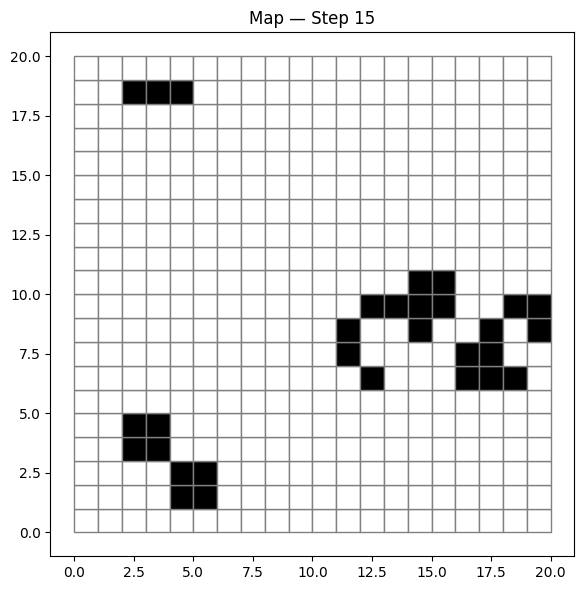

In [9]:
env.run()

## Try it yourself

Go back and experiment:

- Change `end_time` in `Environment` to run more steps
- Change `dimension` in `vector_grid` for a larger grid
- Try `initialize_patterns(["pulsar"])` with a grid >= 15x15
- Try `initialize()` for a fully random start